In [1]:
%load_ext autoreload
%autoreload 2

import pipeline
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import count
import time
import pickle
import shutil
import sys
import itertools
from collections import defaultdict
import geopandas as gpd
from tqdm.auto import tqdm
from libpysal.weights import Queen
import esda
import glob, os, re
from scipy.stats import ks_2samp
import math
from haversine import haversine
from scipy.stats import wasserstein_distance

import plotly.io as pio
pio.renderers.default = "notebook"

seed = 21
interval = '24'
agg = True

if agg:
    if interval == "6":
        fpath = Path('data/agg/DEP_NET_GEOTAX11_14460_20190101_20191231_Tc6_Ts1.csv.gz')
        save_dir = Path(f'data/agg/tests/seed{seed}')
    elif interval == '24':
        fpath = Path('data/agg/DEP_NET_GEOTAX11_14460_20190101_20191231_Tc24_Ts1.csv.gz')
        save_dir = Path(f'data/agg/tests/seed{seed}')
    else:
        print("Invalid time range (must be 24 or 6)")
else:
    if interval == "6":
        fpath = Path('data/poi_level/6h/thresholded_networks/0_network.txt')
        save_dir = Path(f'data/poi_level/6h/tests/seed{seed}')
        data = Path('data/poi_level/depnet_undirected.gz')
    elif interval == '24':
        fpath = Path('data/poi_level/24h/0_network_24h.txt')
        save_dir = Path(f'data/poi_level/24h/tests/seed{seed}')
        data = Path('data/poi_level/24h/depnet_undirected_24h.gz')
    else:
        print("Invalid time range (must be 24 or 6)")

save_dir.mkdir(parents=True, exist_ok=True)

print(f"Interval: {interval} hrs | agg: {agg} | Seed: {seed}")

Interval: 24 hrs | agg: True | Seed: 21


### Agg Network Examination

In [ ]:
_dtypes = {
    'NODE_A': 'category', 'NODE_B': 'category',
    'N_COVISITS': 'float32', 'DIST_KM_MIN': 'float32',
    'DIST_KM_MEAN': 'float32', 'N_UIDS_A': 'float32',
    'N_POIS_A': 'float32', 'N_VISITS_A': 'float32',
    'N_UIDS_B': 'float32', 'N_POIS_B': 'float32', 
    'N_VISITS_B': 'float32', 'DEP': 'float32'
}
df = pd.read_csv(fpath, dtype=_dtypes)

count = ((df['DEP'] != 0) & (df['DEP'].notna())).sum()
print(f'{count}/{df.shape[0]}')
df.head(10)

698320/5288458
N_COVISITS
1.0       3000533
2.0        839649
3.0        384836
4.0        222844
5.0        145726
           ...   
1308.0          1
1153.0          1
1402.0          1
2048.0          1
679.0           1
Name: count, Length: 2030, dtype: int64


,NODE_A,NODE_B,N_COVISITS,DIST_KM_MIN,DIST_KM_MEAN,SELF_LOOP,N_UIDS_A,N_POIS_A,N_VISITS_A,N_UIDS_B,N_POIS_B,N_VISITS_B,DEP
0,25009203100_Transportation,25009210500_Office,1.0,8.509549,8.509549,False,1391.0,25.0,4786.0,896.0,4.0,3812.0,0.0
1,25021418004_Transportation,25025110502_Shopping,1.0,11.437495,11.437495,False,5257.0,53.0,13969.0,2505.0,29.0,5196.0,0.0
2,25017374800_Shopping,25025020101_Personal Care Service,1.0,15.094564,15.094564,False,293.0,7.0,1626.0,1244.0,23.0,2176.0,0.0
3,25017374800_Shopping,25025020200_Food,1.0,15.149967,15.149967,False,293.0,7.0,1626.0,3363.0,12.0,5521.0,0.0
4,25009250500_Food,25009251000_Entertainment,1.0,0.468320,0.468320,False,1718.0,14.0,4196.0,336.0,2.0,655.0,0.0
5,25017353102_Service,25025000100_School,1.0,3.090624,3.090624,False,1667.0,10.0,4818.0,402.0,2.0,877.0,0.0
6,25017313101_Food,25017341200_Grocery,1.0,38.360710,38.360710,False,13086.0,30.0,32604.0,381.0,7.0,889.0,0.0
7,25017353800_Food,25025120301_Food,2.0,5.948961,6.033172,False,3840.0,16.0,6589.0,2660.0,18.0,6302.0,0.0
8,25017331102_Public Administration,25025010203_Food,1.0,23.240080,23.240080,False,742.0,4.0,1793.0,52521.0,61.0,132732.0,0.0
9,25023525104_Service,25023526100_Shopping,2.0,10.721718,10.827007,False,332.0,4.0,865.0,5262.0,15.0,22087.0,0.0


N_COVISITS
1.0       3000533
2.0        839649
3.0        384836
4.0        222844
5.0        145726
           ...   
1308.0          1
1153.0          1
1402.0          1
2048.0          1
679.0           1
Name: count, Length: 2030, dtype: int64


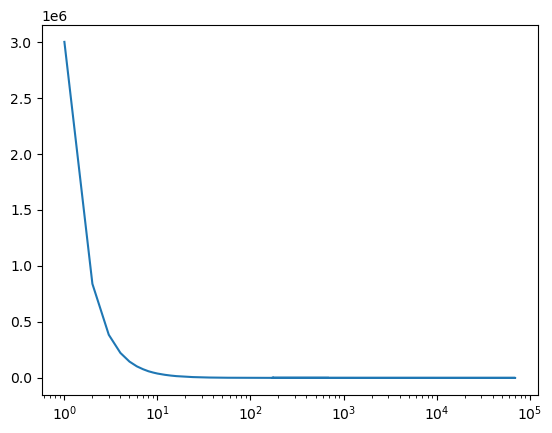

In [5]:
plt.semilogx(df['N_COVISITS'].value_counts())
print(df['N_COVISITS'].value_counts())


In [7]:
G, train_non_edges, test_pos_edges, test_non_edges = pipeline.prepare_data(fpath, test_frac=0.25, controlled=False, meta=True)

Nodes: 15831
Edges: 5288458


sampling non-edges:   0%|          | 0/1322114 [00:00<?, ?edge/s]

sampling non-edges:   0%|          | 0/3966344 [00:00<?, ?edge/s]

Wrote training graph: 15831 nodes, 3966344 edges


In [8]:
# checking unmatched distribution of weak vs strong class

trainfile = 'train.txt'
G_train = nx.read_edgelist(
    trainfile, data=[('weight', float)], delimiter='\t')
train_pos_edges = [tuple(sorted(e)) for e in G_train.edges()]

def _dep(edges, keep):
    return np.array([G[u][v]['DEP'] for u, v in edges],
                    dtype=np.float64)[keep]

keep_train_pos = list(range(len(train_pos_edges)))
keep_test_pos = list(range(len(test_pos_edges)))

dep_train = _dep(train_pos_edges, keep_train_pos)
dep_test = _dep(test_pos_edges, keep_test_pos)
dep_all = np.concatenate((dep_train, dep_test))

dep_train = dep_train[dep_train > 0]
dep_test = dep_test[dep_test > 0]
dep_all = dep_all[dep_all > 0]

thr_train = np.quantile(dep_train, 0.5)
thr_test = np.quantile(dep_test, 0.5)
thr_all = np.quantile(dep_all, 0.5)

train_mask = dep_train > thr_train
dep_train_strong = np.sort(dep_train[train_mask])
dep_train_weak = np.sort(dep_train[~train_mask])
print(f'Train thr = {thr_train}')

test_mask = dep_test > thr_test
dep_test_strong = np.sort(dep_test[test_mask])
dep_test_weak = np.sort(dep_test[~test_mask])
print(f'Test thr = {thr_test}')

all_mask = dep_all > thr_all
dep_all_strong = np.sort(dep_all[all_mask])
dep_all_weak = np.sort(dep_all[~all_mask])
print(f'Overall thr = {thr_all}')

Train thr = 9.999999974752427e-07
Test thr = 9.999999974752427e-07
Overall thr = 9.999999974752427e-07


In [9]:
# confirm the floor pileup in nonzero DEP

floor_val = np.float32(1e-6)
n_at_floor = (dep_all == floor_val).sum()
print(f"Nonzero DEP edges: {len(dep_all)}")
print(f"Edges exactly at floor ({floor_val}): {n_at_floor} ({n_at_floor / len(dep_all):.2%})")

# most common nonzero DEP values
vals, counts = np.unique(dep_all, return_counts=True)
order = np.argsort(counts)[::-1]
print("\nTop 10 most common nonzero DEP values:")
for v, c in zip(vals[order][:10], counts[order][:10]):
    print(f"  {v:.6e} : {c} edges ({c / len(dep_all):.2%})")

# quantile sweep to see where the distribution escapes the floor pileup
print("\nQuantile sweep:")
for q in [0.5, 0.7, 0.8, 0.87, 0.9, 0.95, 0.99]:
    print(f"  q={q:.2f} -> {np.quantile(dep_all, q):.6e}")

Nonzero DEP edges: 698320
Edges exactly at floor (9.999999974752427e-07): 451068 (64.59%)

Top 10 most common nonzero DEP values:
  1.000000e-06 : 451068 edges (64.59%)
  2.000000e-06 : 107247 edges (15.36%)
  3.000000e-06 : 46714 edges (6.69%)
  4.000000e-06 : 25130 edges (3.60%)
  5.000000e-06 : 15469 edges (2.22%)
  6.000000e-06 : 10132 edges (1.45%)
  7.000000e-06 : 7260 edges (1.04%)
  8.000000e-06 : 5232 edges (0.75%)
  9.000000e-06 : 4122 edges (0.59%)
  1.000000e-05 : 3267 edges (0.47%)

Quantile sweep:
  q=0.50 -> 1.000000e-06
  q=0.70 -> 2.000000e-06
  q=0.80 -> 3.000000e-06
  q=0.87 -> 4.000000e-06
  q=0.90 -> 4.000000e-06
  q=0.95 -> 8.000000e-06
  q=0.99 -> 2.500000e-05


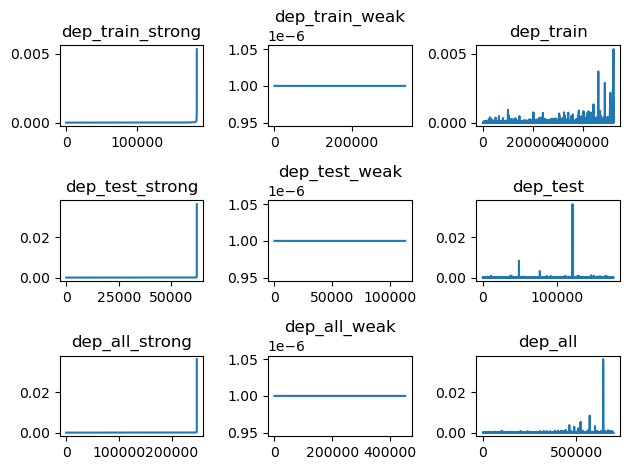

In [12]:
# plot

fig, ax = plt.subplots(3, 3)

order = [dep_train_strong, dep_train_weak, dep_train,
         dep_test_strong, dep_test_weak, dep_test,
         dep_all_strong, dep_all_weak, dep_all]
titles = ['dep_train_strong', 'dep_train_weak', 'dep_train',
         'dep_test_strong', 'dep_test_weak', 'dep_test',
         'dep_all_strong', 'dep_all_weak', 'dep_all']

cur_row_idx = 0
cur_col_idx = 0
for i, _class in enumerate(order):
    ax[cur_row_idx, cur_col_idx].plot(_class)
    ax[cur_row_idx, cur_col_idx].set_title(titles[i])
    if i in [2, 5]:
        cur_col_idx = 0
        cur_row_idx += 1
    else:
        cur_col_idx += 1

plt.tight_layout()

In [ ]:
# bugfix pipeline

G = pipeline.load(fpath)
dep_edges = sum(1 for _, _, d in G.edges(data=True) if d.get('DEP', 0) != 0)
total_edges = G.number_of_edges()

print(f"{dep_edges}/{total_edges}")

### Thresholded Network Build (POI-level)

In [ ]:
# --- dependency distribution ---

# reading in + dealing with missing values
df = pd.read_csv(data)
df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
df = df.dropna(subset=['DEP'])

# sampling for performance
plot_data = df['DEP'].sample(100000)
print(plot_data.describe())

sns.displot(plot_data, bins=30, kde=True, stat='probability', log_scale=True)
plt.margins(x=0)

# --- num removed vs binned values ---

dep_nonzero = df.loc[df['DEP'] > 0, 'DEP'].sort_values().values
total_edges = len(df)
zero_edges = total_edges - len(dep_nonzero)

print(f"Total edges: {total_edges}")
print(f"Zero-DEP edges: {zero_edges}")
print(f"Nonzero DEP range: [{dep_nonzero.min():.2e}, {dep_nonzero.max():.2e}]")

# log-spaced bins across the nonzero DEP range
bins = np.logspace(np.log10(dep_nonzero.min()), np.log10(dep_nonzero.max()), 200)

# for each threshold, edges retained = nonzero edges with DEP >= threshold
edges_retained = len(dep_nonzero) - np.searchsorted(dep_nonzero, bins, side='left')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bins, edges_retained)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('DEP threshold')
ax.set_ylabel('Number of edges retained')
ax.set_title('Edges retained vs DEP threshold')

ax.axhline(y=1_000_000, color='r', linestyle='--', label='1M edges')
ax.axhline(y=10_000, color='orange', linestyle='--', label='10k edges')
ax.legend()
plt.show()

# find approximate thresholds
vals = []
for target, label in [(1_000_000, 'DEP_low (~1M)'), (10_000, 'DEP_high (~10k)')]:
    idx = np.argmin(np.abs(edges_retained - target))
    vals.append(bins[idx])
    print(f"{label}: DEP â‰ˆ {bins[idx]:.6e}, edges retained = {edges_retained[idx]}")

DEP_low = vals[0]
DEP_high = vals[1]

In [ ]:
all = 0

# reloading df if needed
if 'df' not in globals():
    df = pd.read_csv(data)
    df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
    df = df.dropna(subset=['DEP'])

if all:
    # filtering
    DEP_range = df[df['DEP'].between(DEP_low, DEP_high)]
    # calculating thresholds with bounded range
    quantiles = np.quantile(DEP_range['DEP'], [0.25, 0.5, 0.75])
    thresholds = np.concatenate([[DEP_low], quantiles, [DEP_high]])

    # creating networks with original uncapped df
    for i, threshold in zip(count(0, 0.25), thresholds):
        # filter
        thresholded_df = df[df['DEP'] >= threshold]
        
        # save df directly
        filepath = f'data/undir_trials/thresholded_networks/{i}_network.txt'
        thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
        
        print(f"Saved {filepath} with {len(thresholded_df)} edges")
else:
    thresholded_df = df[df['DEP'] >= DEP_low]
    filepath = f'data/undir_trials/24h/network.txt'
    thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
    print(f"Saved {filepath} with {len(thresholded_df)} edges")